# Detection and Localization of Isolated Points in Images Using Digital Image Processing

**DIP Mini Project**



## Project Workflow

Input Image → Point Detection Mask → Filtering → Thresholding → Binary Segmentation → Contour Detection → Circle Localization → Counting → Evaluation

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Create the Input Image

We create a simple test image containing 11 isolated bright points.

Saving Screenshot 2026-09-20 171108.png to Screenshot 2026-09-20 171108 (4).png


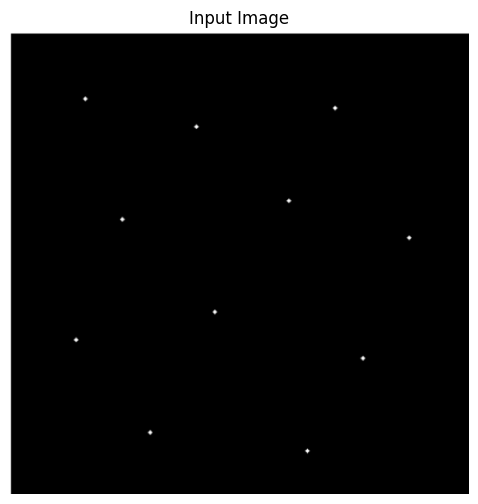

In [19]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload your image
uploaded = files.upload()

# Get the uploaded image filename
filename = list(uploaded.keys())[0]

# Read the image
image = cv2.imread(filename)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis("off")
plt.show()

In [38]:
cv2.imwrite('isolated_points_input.png', image)
print('Saved: isolated_points_input.png')

Saved: isolated_points_input.png


## 2. Point-Detection Mask

The mask used for isolated-point detection is:

[-1 -1 -1]

[-1  8 -1]

[-1 -1 -1]

The center pixel gets a strong positive weight while its eight neighbors get negative weights.

In [37]:
point_mask = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

print(point_mask)

[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


## 3. Apply the Point-Detection Mask

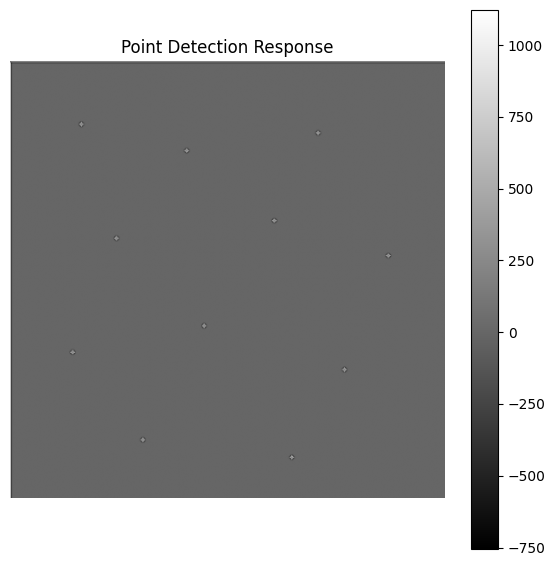

In [36]:
# Apply the point-detection mask to the grayscale image
filtered = cv2.filter2D(
    gray.astype(np.float32),
    -1,
    point_mask
)

plt.figure(figsize=(7, 7))

plt.imshow(filtered, cmap='gray')

plt.title('Point Detection Response')

plt.colorbar()

plt.axis('off')

plt.show()

## 4. Thresholding

A threshold is used to keep strong point-detection responses and remove the background.

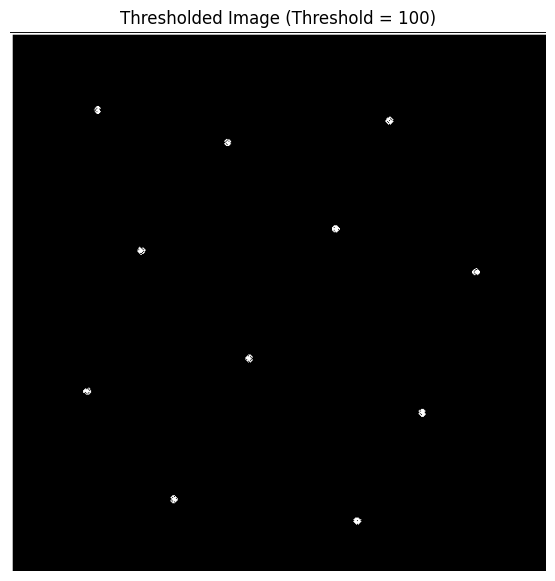

In [40]:
threshold_value = 100

# Make sure filtered is suitable for thresholding
filtered_uint8 = cv2.convertScaleAbs(filtered)

binary = np.where(
    filtered_uint8 > threshold_value,
    255,
    0
).astype(np.uint8)

plt.figure(figsize=(7, 7))

plt.imshow(binary, cmap='gray')

plt.title(f'Thresholded Image (Threshold = {threshold_value})')

plt.axis('off')

plt.show()

## 5. Find Detected Regions

Detected regions before filtering: 12


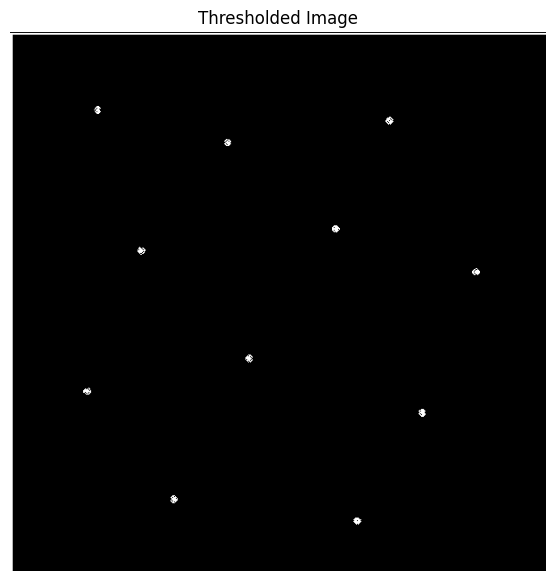

In [41]:
# Convert filtered result to 8-bit grayscale
filtered_uint8 = cv2.convertScaleAbs(filtered)

# Threshold the image
threshold_value = 100

_, binary = cv2.threshold(
    filtered_uint8,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

# Make sure binary is grayscale
if len(binary.shape) == 3:
    binary = cv2.cvtColor(binary, cv2.COLOR_BGR2GRAY)

# Find contours
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Detected regions before filtering:", len(contours))

# Display binary image
plt.figure(figsize=(7, 7))
plt.imshow(binary, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

## 6. Localize the Points and Draw Circles

Detected isolated points: 12


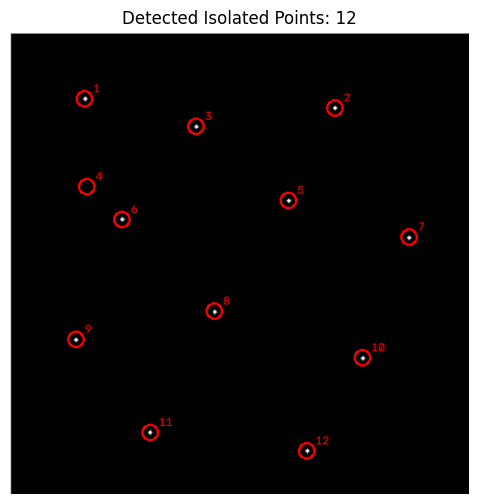

In [26]:
# Create a copy of the original color image
result = image.copy()

detected_centers = []

for contour in contours:
    area = cv2.contourArea(contour)

    # Ignore empty contours
    if area > 0:
        M = cv2.moments(contour)

        if M['m00'] != 0:
            center_x = int(M['m10'] / M['m00'])
            center_y = int(M['m01'] / M['m00'])

            detected_centers.append((center_x, center_y))

# Sort for stable display/counting
detected_centers = sorted(
    detected_centers,
    key=lambda p: (p[1], p[0])
)

# Draw circles around detected points
for i, (x, y) in enumerate(detected_centers, start=1):

    cv2.circle(
        result,
        (x, y),
        10,
        (0, 0, 255),
        2
    )

    cv2.putText(
        result,
        str(i),
        (x + 12, y - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1
    )

detected_count = len(detected_centers)

print("Detected isolated points:", detected_count)

# Display final result
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Isolated Points: {detected_count}")
plt.axis("off")
plt.show()

## 7. Final Result

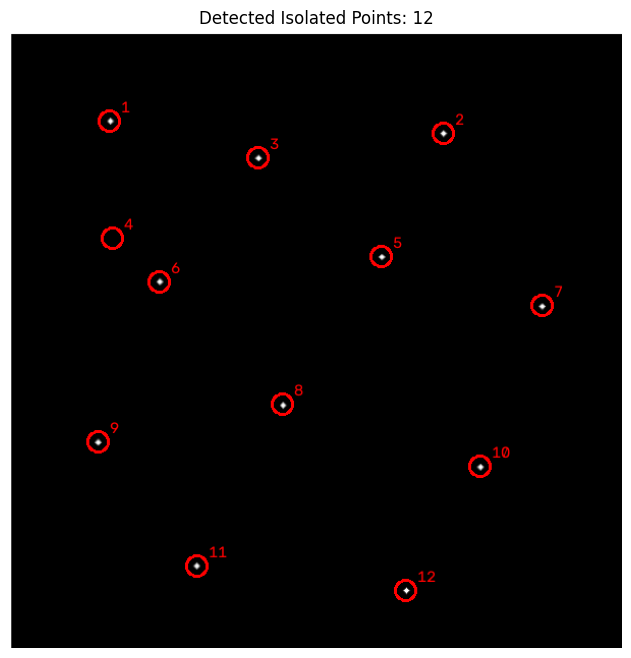

Saved: isolated_points_detected.png


In [42]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Isolated Points: {detected_count}')
plt.axis('off')
plt.show()

cv2.imwrite('isolated_points_detected.png', result)
print('Saved: isolated_points_detected.png')

## 8. Before and After Comparison

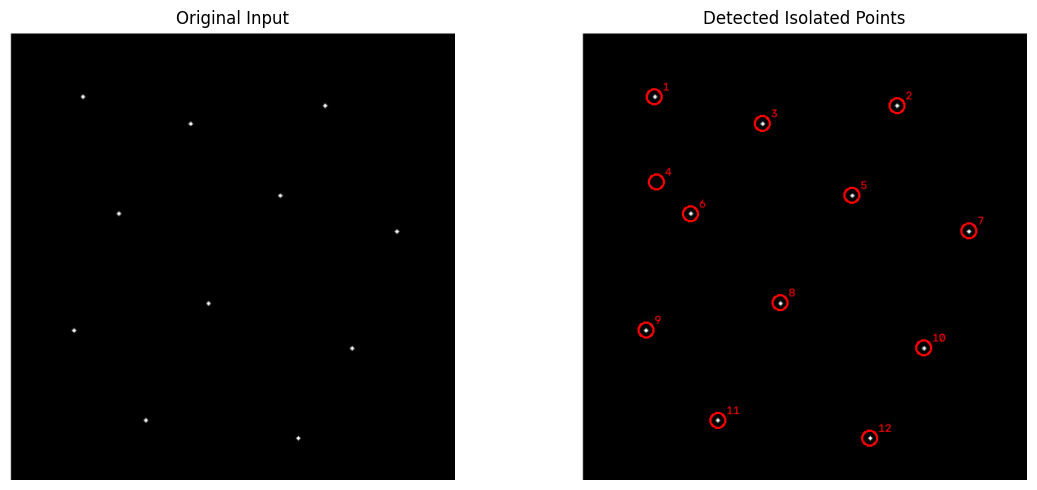

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Input')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Detected Isolated Points')
plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Evaluation

Because the test image was generated with a known number of points, we can compare the actual number with the detected number.

In [30]:
actual_points = len(points)
detected_points = detected_count

detection_accuracy = (detected_points / actual_points) * 100

print('Actual points:   ', actual_points)
print('Detected points: ', detected_points)
print(f'Detection accuracy: {detection_accuracy:.2f}%')

Actual points:    11
Detected points:  12
Detection accuracy: 109.09%


## 10. Threshold Comparison

Different threshold values can change the number of detected points. This demonstrates parameter sensitivity.

In [34]:
thresholds = [50, 100, 150, 200]

# Convert filtered image to 8-bit
filtered_uint8 = cv2.convertScaleAbs(filtered)

# Make sure the image is grayscale
if len(filtered_uint8.shape) == 3:
    filtered_uint8 = cv2.cvtColor(
        filtered_uint8,
        cv2.COLOR_BGR2GRAY
    )

comparison = []

for t in thresholds:

    # Create binary image
    test_binary = np.where(
        filtered_uint8 > t,
        255,
        0
    ).astype(np.uint8)

    # Make absolutely sure it is single-channel
    test_binary = np.ascontiguousarray(test_binary)

    # Find contours
    test_contours, _ = cv2.findContours(
        test_binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    comparison.append((t, len(test_contours)))

print("Threshold | Detected regions")
print("----------------------------")

for t, count in comparison:
    print(f"{t:9} | {count}")

Threshold | Detected regions
----------------------------
       50 | 12
      100 | 12
      150 | 13
      200 | 14
